In [1]:
#Today's Lab Task
#Linear Regression baseline
#Ridge and Lasso regression to prevent overfitting
#Performance evaluation (RMSE, R²)
#Comparison of coefficients and generalization

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, r2_score

# Set style for plots
sns.set_style("whitegrid")
%matplotlib inline

In [31]:
# 2. Load Dataset
# Load the CSV file (make sure housing.csv is in the same folder)
df = pd.read_csv('housing.csv')

# Quick look at the data
print("Dataset shape:", df.shape) # shape == (row, column)
df.head()

Dataset shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [33]:
#Data Pre-Processing / Data Cleaning
# Check for missing values
print("Missing values per column:\n", df.isnull().sum())

# Drop rows with missing values (or impute – here we drop for simplicity) / Drops any row with at least one missing value.
df.dropna(inplace=True)
print(f"After dropping NaNs: {df.shape}")

# Separate features and target
target_col = 'median_house_value'
X = df.drop(columns=[target_col])
y = df[target_col]

# Convert categorical 'ocean_proximity' to one-hot encoding ( Missing values would break regression; dropping is simple but may lose data. One‑hot encoding turns text into numbers.)
X = pd.get_dummies(X, columns=['ocean_proximity'], drop_first=True) # Converts the categorical column ocean_proximity into dummy (binary) variables. drop_first=True avoids multicollinearity.

print("Features after encoding:", list(X.columns))

Missing values per column:
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
After dropping NaNs: (20433, 10)
Features after encoding: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


In [35]:
# Train test Split and Scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features (important for Ridge and Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train_scaled.shape[0]}, Test size: {X_test_scaled.shape[0]}")

Train size: 16346, Test size: 4087


In [37]:
#Liner Regression (Baseline)
#Trains ordinary least squares (OLS) linear regression, predicts on train and test sets, then calculates RMSE (Root Mean Squared Error) and R² (coefficient of determination).
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_train_pred = lr.predict(X_train_scaled)
y_test_pred = lr.predict(X_test_scaled)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Linear Regression Performance:")
print(f"Train RMSE: {train_rmse:.2f} | Test RMSE: {test_rmse:.2f}")
print(f"Train R²  : {train_r2:.4f} | Test R²  : {test_r2:.4f}")

Linear Regression Performance:
Train RMSE: 68487.31 | Test RMSE: 69297.72
Train R²  : 0.6456 | Test R²  : 0.6488


In [39]:
#Ridge Regression (L2 penalty) with cross-validation
alphas = np.logspace(-3, 3, 50)
ridge = RidgeCV(alphas=alphas, scoring='neg_mean_squared_error', cv=5)
ridge.fit(X_train_scaled, y_train)

print(f"Best alpha for Ridge: {ridge.alpha_:.4f}")

y_train_pred_ridge = ridge.predict(X_train_scaled)
y_test_pred_ridge = ridge.predict(X_test_scaled)

train_rmse_ridge = np.sqrt(mean_squared_error(y_train, y_train_pred_ridge))
test_rmse_ridge = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))
train_r2_ridge = r2_score(y_train, y_train_pred_ridge)
test_r2_ridge = r2_score(y_test, y_test_pred_ridge)

print("\nRidge Regression Performance:")
print(f"Train RMSE: {train_rmse_ridge:.2f} | Test RMSE: {test_rmse_ridge:.2f}")
print(f"Train R²  : {train_r2_ridge:.4f} | Test R²  : {test_r2_ridge:.4f}")

Best alpha for Ridge: 25.5955

Ridge Regression Performance:
Train RMSE: 68491.77 | Test RMSE: 69303.35
Train R²  : 0.6456 | Test R²  : 0.6488


In [43]:
#Lasso Regression (L1 penalty) with cross‑validation
lasso = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

print(f"Best alpha for Lasso: {lasso.alpha_:.4f}")

y_train_pred_lasso = lasso.predict(X_train_scaled)
y_test_pred_lasso = lasso.predict(X_test_scaled)

train_rmse_lasso = np.sqrt(mean_squared_error(y_train, y_train_pred_lasso))
test_rmse_lasso = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))
train_r2_lasso = r2_score(y_train, y_train_pred_lasso)
test_r2_lasso = r2_score(y_test, y_test_pred_lasso)

print("\nLasso Regression Performance:")
print(f"Train RMSE: {train_rmse_lasso:.2f} | Test RMSE: {test_rmse_lasso:.2f}")
print(f"Train R²  : {train_r2_lasso:.4f} | Test R²  : {test_r2_lasso:.4f}")

Best alpha for Lasso: 59.6362

Lasso Regression Performance:
Train RMSE: 68490.22 | Test RMSE: 69301.83
Train R²  : 0.6456 | Test R²  : 0.6488


In [45]:
#Performance comparison table
results = pd.DataFrame({
    'Model': ['Linear', 'Ridge', 'Lasso'],
    'Train RMSE': [train_rmse, train_rmse_ridge, train_rmse_lasso],
    'Test RMSE': [test_rmse, test_rmse_ridge, test_rmse_lasso],
    'Train R²': [train_r2, train_r2_ridge, train_r2_lasso],
    'Test R²': [test_r2, test_r2_ridge, test_r2_lasso]
})
results = results.round(4)
print("Comparison of Models:")
display(results)

# Overfitting gap
results['Overfitting Gap (RMSE)'] = results['Train RMSE'] - results['Test RMSE']
print("\nOverfitting Gap (negative = test error > train error):")
display(results[['Model', 'Overfitting Gap (RMSE)']])

Comparison of Models:


,Model,Train RMSE,Test RMSE,Train R²,Test R²
0,Linear,68487.3067,69297.7167,0.6456,0.6488
1,Ridge,68491.7716,69303.3457,0.6456,0.6488
2,Lasso,68490.2243,69301.8312,0.6456,0.6488



Overfitting Gap (negative = test error > train error):


,Model,Overfitting Gap (RMSE)
0,Linear,-810.4100
1,Ridge,-811.5741
2,Lasso,-811.6069


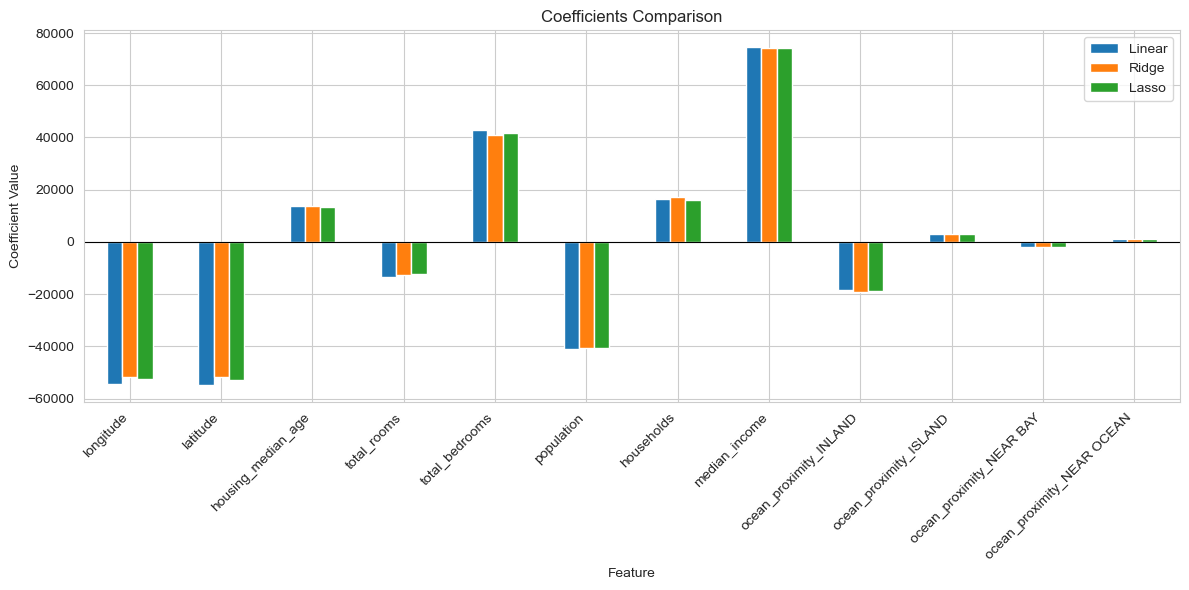

In [47]:
#Coefficient comparison
coef_lr = lr.coef_
coef_ridge = ridge.coef_
coef_lasso = lasso.coef_

feature_names = X.columns

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Linear': coef_lr,
    'Ridge': coef_ridge,
    'Lasso': coef_lasso
})
coef_df.set_index('Feature', inplace=True)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
coef_df.plot(kind='bar', ax=ax)
ax.set_title('Coefficients Comparison')
ax.set_ylabel('Coefficient Value')
ax.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

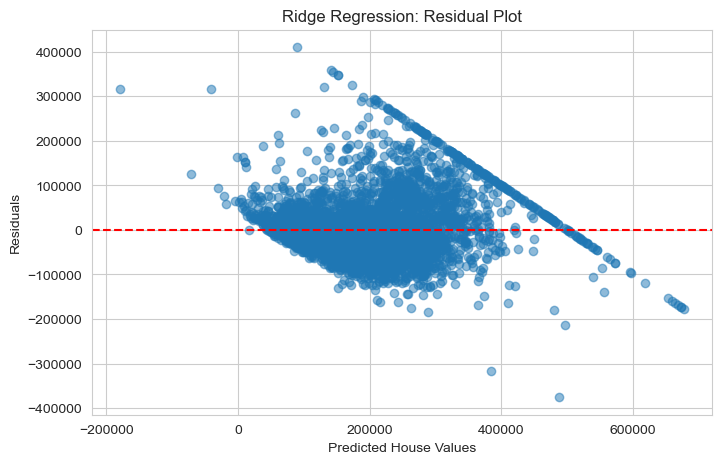

In [25]:
#Residual plot (example with Ridge)
residuals = y_test - y_test_pred_ridge
plt.figure(figsize=(8,5))
plt.scatter(y_test_pred_ridge, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted House Values')
plt.ylabel('Residuals')
plt.title('Ridge Regression: Residual Plot')
plt.show()